#📌 Extracción

In [627]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots

requests

<module 'requests' from '/usr/local/lib/python3.12/dist-packages/requests/__init__.py'>

In [628]:
url = "https://raw.githubusercontent.com/juu11/Alura-Challenge-Telecom-X/refs/heads/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [629]:
print("identificación de datos nulos, o vacios \n", df.isnull().sum())
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

identificación de datos nulos, o vacios 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [630]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


#🔧 Transformación

 **Exploración**

*   Explorar las columnas del dataset y verificar sus tipos de datos.
*   Consultar el diccionario para comprender mejor el significado de las variables.
*   Identificar las columnas más relevantes para el análisis de evasión.



In [631]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [632]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


- *account.Charges.Monthly*  y *account.Charges.Total* deberían ser del mismo tipo de dato.

**Diccionario de datos**


*   **customerID:** número de identificación único de cada cliente
*   **Churn:** si el cliente dejó o no la empresa
*   **gender:** género (masculino y femenino)
*   **SeniorCitizen:** información sobre si un cliente tiene o no una edad igual o mayor a 65 años
*   **Partner:** si el cliente tiene o no una pareja
*   **Dependents:** si el cliente tiene o no dependientes
*   **tenure:** meses de contrato del cliente
*   **PhoneService:** suscripción al servicio telefónico
*   **MultipleLines:** suscripción a más de una línea telefónica
*   **InternetService:** suscripción a un proveedor de internet
*   **OnlineSecurity:** suscripción adicional de seguridad en línea
*   **OnlineBackup:** suscripción adicional de respaldo en línea
*   **DeviceProtection:** suscripción adicional de protección del dispositivo
*   **TechSupport:** suscripción adicional de soporte técnico, menor tiempo de espera
*   **StreamingTV:** suscripción de televisión por cable
*   **StreamingMovies:** suscripción de streaming de películas
*   **Contract:** tipo de contrato
*   **PaperlessBilling:** si el cliente prefiere recibir la factura en línea
*  **PaymentMethod:** forma de pago
*   **Charges.Monthly:** total de todos los servicios del cliente por mes
*   **Charges.Total:** total gastado por el cliente



**Comprobación de incoherencias en los datos**


En este paso, verifica si hay problemas en los datos que puedan afectar el análisis. Presta atención a valores ausentes, duplicados, errores de formato e inconsistencias en las categorías. Este proceso es esencial para asegurarte de que los datos estén listos para las siguientes etapas.


- Comprobación de valores nulos

In [633]:
print(df.isnull().sum())

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


- Revision de valores unicos

In [634]:
for column in df.columns[1:]:
    valore_unicos = df[column].sort_values().unique()
    if len(valore_unicos) < 10:
        print(column, '\n',valore_unicos, '\n')
    else:
        print(column, '\nMin:',min(valore_unicos), '\t Max:', max(valore_unicos), '\n')

Churn 
 ['' 'No' 'Yes'] 

customer.gender 
 ['Female' 'Male'] 

customer.SeniorCitizen 
 [0 1] 

customer.Partner 
 ['No' 'Yes'] 

customer.Dependents 
 ['No' 'Yes'] 

customer.tenure 
Min: 0 	 Max: 72 

phone.PhoneService 
 ['No' 'Yes'] 

phone.MultipleLines 
 ['No' 'No phone service' 'Yes'] 

internet.InternetService 
 ['DSL' 'Fiber optic' 'No'] 

internet.OnlineSecurity 
 ['No' 'No internet service' 'Yes'] 

internet.OnlineBackup 
 ['No' 'No internet service' 'Yes'] 

internet.DeviceProtection 
 ['No' 'No internet service' 'Yes'] 

internet.TechSupport 
 ['No' 'No internet service' 'Yes'] 

internet.StreamingTV 
 ['No' 'No internet service' 'Yes'] 

internet.StreamingMovies 
 ['No' 'No internet service' 'Yes'] 

account.Contract 
 ['Month-to-month' 'One year' 'Two year'] 

account.PaperlessBilling 
 ['No' 'Yes'] 

account.PaymentMethod 
 ['Bank transfer (automatic)' 'Credit card (automatic)' 'Electronic check'
 'Mailed check'] 

account.Charges.Monthly 
Min: 18.25 	 Max: 118.75 

ac

In [635]:
for col in df.columns:
  print(f'{col}: {df[col].nunique()}')

customerID: 7267
Churn: 3
customer.gender: 2
customer.SeniorCitizen: 2
customer.Partner: 2
customer.Dependents: 2
customer.tenure: 73
phone.PhoneService: 2
phone.MultipleLines: 3
internet.InternetService: 3
internet.OnlineSecurity: 3
internet.OnlineBackup: 3
internet.DeviceProtection: 3
internet.TechSupport: 3
internet.StreamingTV: 3
internet.StreamingMovies: 3
account.Contract: 3
account.PaperlessBilling: 2
account.PaymentMethod: 4
account.Charges.Monthly: 1585
account.Charges.Total: 6531


- Revición de valores incoherentes

In [636]:
## Usar lambda en Pandas es ideal para aplicar transformaciones rápidas y personalizadas en DataFrames, generalmente combinada con .apply()
## para filas/columnas o .map()/.applymap() para elementos.
## La sintaxis básica es df['columna'].apply(lambda x: expresión), donde x representa cada valor individual

df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


- Cambio de tipo de datos para la columna account.Charges.Total

In [637]:
df['account.Charges.Total'] = df['account.Charges.Total'].apply(pd.to_numeric, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [638]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


- Conversión de datos vacios a NaN en la columna account.Charges.Total

In [639]:
df[df['account.Charges.Total'].isna()]

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


- Valores de la columna Churn vacios son eliminados

In [640]:
df = df[df['Churn'].str.strip() != '']
df = df.dropna(subset=['account.Charges.Total']) ## eliminacion de datos NaN en account.Charges.Total
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


- Valores unicos actualizados

In [641]:
for col in df.columns:
  print(f'{col}: {df[col].nunique()}')

customerID: 7032
Churn: 2
customer.gender: 2
customer.SeniorCitizen: 2
customer.Partner: 2
customer.Dependents: 2
customer.tenure: 72
phone.PhoneService: 2
phone.MultipleLines: 3
internet.InternetService: 3
internet.OnlineSecurity: 3
internet.OnlineBackup: 3
internet.DeviceProtection: 3
internet.TechSupport: 3
internet.StreamingTV: 3
internet.StreamingMovies: 3
account.Contract: 3
account.PaperlessBilling: 2
account.PaymentMethod: 4
account.Charges.Monthly: 1584
account.Charges.Total: 6530


- Confirmación de valores nulos

In [642]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


- Columna de cuentas diarias

Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

In [643]:
df['cuentas_diarias'] = df['account.Charges.Monthly'] / 30
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


- Estandarización y transformación de datos

La estandarización y transformación de datos es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más consistente, comprensible y adecuada para el análisis. Durante esta fase, por ejemplo, puedes convertir valores textuales como "Sí" y "No" en valores binarios (1 y 0), lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

Además, traducir o renombrar columnas y datos hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos.

In [644]:
# Traduccion de los nombres de las columnas.
columnas = {
    'customerID': 'ID',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'veterano',
    'customer.Partner': 'posee_pareja',
    'customer.Dependents': 'posee_dependientes',
    'customer.tenure': 'tiempo_contrato',
    'phone.PhoneService': 'servicio_telefono',
    'phone.MultipleLines': 'multiples_lineas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_digital',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'valor_mensual',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns= columnas)

#Traduccion de los registros de la tabla.

df['genero'] = df['genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
df['multiples_lineas'] = df['multiples_lineas'].replace({'No phone service': 'Sin servicio de teléfono'})
df['tipo_internet'] = df['tipo_internet'].replace({'No': '0', 'Fiber optic': 'Fibra óptica'})
df['seguridad_online'] = df['seguridad_online'].replace({'No internet service': 'Sin servicio de internet'})
df['backup_online'] = df['backup_online'].replace({'No internet service': 'Sin servicio de internet'})
df['proteccion_dispositivo'] = df['proteccion_dispositivo'].replace({'No internet service': 'Sin servicio de internet'})
df['soporte_tecnico'] = df['soporte_tecnico'].replace({'No internet service': 'Sin servicio de internet'})
df['streaming_tv'] = df['streaming_tv'].replace({'No internet service': 'Sin servicio de internet'})
df['streaming_peliculas'] = df['streaming_peliculas'].replace({'No internet service': 'Sin servicio de internet'})
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensual', 'Two year': 'Bienal'})
df['metodo_pago'] = df['metodo_pago'].replace({
    'Mailed check': 'Cheque enviado por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automático)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)'
})

# conversion de valores textuales en binarios.

binarios = [
    'Churn',
    'posee_pareja',
    'posee_dependientes',
    'servicio_telefono',
    'multiples_lineas',
    'seguridad_online',
    'backup_online',
    'proteccion_dispositivo',
    'soporte_tecnico',
    'streaming_tv',
    'streaming_peliculas',
    'factura_digital'
]

for col in binarios:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0
        })


#📊 Carga y análisis

- Análisis Descriptivo

Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

In [645]:
describe = df.describe()
formatted = describe.astype(object)


binarias = [
    'Churn', 'veterano', 'posee_pareja', 'posee_dependientes',
    'servicio_telefono', 'multiples_lineas', 'tipo_internet', 'seguridad_online',
    'backup_online', 'proteccion_dispositivo', 'soporte_tecnico',
    'streaming_tv', 'streaming_peliculas', 'factura_digital'
]

for col in binarias:
    if col in describe.columns:
        for idx in formatted.index:
            if idx == 'count':
                formatted.loc[idx, col] = f"{int(describe.loc[idx, col])}"
            else:
                formatted.loc[idx, col] = f"{describe.loc[idx, col]*100:.1f}%"


monetarias = ['valor_mensual', 'total_cobrado', 'cuentas_diarias']
for col in monetarias:
    if col in describe.columns:
        for idx in formatted.index:
            if idx == 'count':
                formatted.loc[idx, col] = f"{int(describe.loc[idx, col])}"
            else:
                formatted.loc[idx, col] = f"${describe.loc[idx, col]:,.1f}"


contrato = 'tiempo_contrato'
if contrato in describe.columns:
    for idx in formatted.index:
        if idx == 'count':
            formatted.loc[idx, contrato] = f"{int(describe.loc[idx, contrato])}"
        else:
            formatted.loc[idx, contrato] = f"{describe.loc[idx, contrato]:.1f}"


display(formatted)


print("\nResumen de las  métricas:")
print(f"- churn: {describe.loc['mean','Churn']*100:.1f}% de clientes cancelaron.")
print(f"- veterano: {describe.loc['mean','veterano']*100:.1f}% son adultos mayores.")
print(f"- posee_pareja: {describe.loc['mean','posee_pareja']*100:.1f}% tienen pareja.")
print(f"- posee_dependientes: {describe.loc['mean','posee_dependientes']*100:.1f}% tienen dependientes.")
print(f"- tiempo_contrato: mediana = {describe.loc['50%','tiempo_contrato']:.1f} meses, máximo = {describe.loc['max','tiempo_contrato']:.1f} meses.")
print(f"- valor mensual: media = ${describe.loc['mean','valor_mensual']:.1f}, mediana = ${describe.loc['50%','valor_mensual']:.1f}.")
print(f"- total cobrado: media = ${describe.loc['mean','total_cobrado']:.1f}, mediana = ${describe.loc['50%','total_cobrado']:.1f}, máximo = ${describe.loc['max','total_cobrado']:.1f}.")
print(f"- cuentas diarias: media = ${describe.loc['mean','cuentas_diarias']:.1f}, mediana = ${describe.loc['50%','cuentas_diarias']:.1f}.")



,Churn,veterano,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,factura_digital,valor_mensual,total_cobrado,cuentas_diarias
count,7032,7032,7032,7032,7032,7032,6352,5512,5512,5512,5512,5512,5512,7032,7032,7032,7032
mean,26.6%,16.2%,48.3%,29.8%,32.4,90.3%,46.7%,36.6%,44.0%,43.9%,37.0%,49.0%,49.5%,59.3%,$64.8,"$2,283.3",$2.2
std,44.2%,36.9%,50.0%,45.8%,24.5,29.6%,49.9%,48.2%,49.6%,49.6%,48.3%,50.0%,50.0%,49.1%,$30.1,"$2,266.8",$1.0
min,0.0%,0.0%,0.0%,0.0%,1.0,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,$18.2,$18.8,$0.6
25%,0.0%,0.0%,0.0%,0.0%,9.0,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,$35.6,$401.4,$1.2
50%,0.0%,0.0%,0.0%,0.0%,29.0,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,100.0%,$70.3,"$1,397.5",$2.3
75%,100.0%,0.0%,100.0%,100.0%,55.0,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,$89.9,"$3,794.7",$3.0
max,100.0%,100.0%,100.0%,100.0%,72.0,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,$118.8,"$8,684.8",$4.0



Resumen de las  métricas:
- churn: 26.6% de clientes cancelaron.
- veterano: 16.2% son adultos mayores.
- posee_pareja: 48.3% tienen pareja.
- posee_dependientes: 29.8% tienen dependientes.
- tiempo_contrato: mediana = 29.0 meses, máximo = 72.0 meses.
- valor mensual: media = $64.8, mediana = $70.3.
- total cobrado: media = $2283.3, mediana = $1397.5, máximo = $8684.8.
- cuentas diarias: media = $2.2, mediana = $2.3.


- Recuento de evasión por variables categóricas

Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

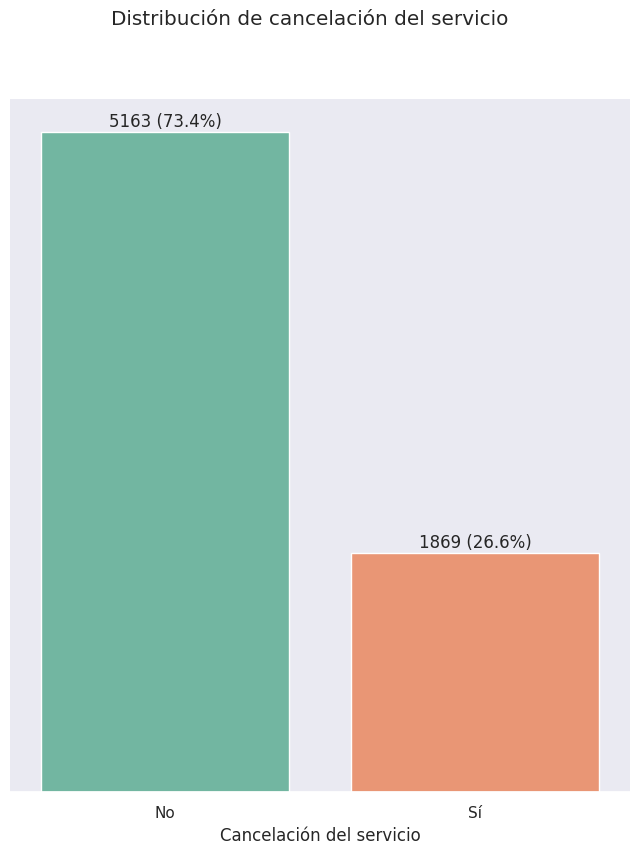

In [646]:

fig, ax = plt.subplots(figsize=(8, 9))
fig.suptitle('Distribución de cancelación del servicio')
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', ax=ax)
ax.set_xlabel('Cancelación del servicio')
ax.set_ylabel('')
ax.xaxis.set_ticks([0, 1])
ax.xaxis.set_ticklabels(['No', 'Sí'])
ax.yaxis.set_ticklabels([])
ax.yaxis.set_ticks(ticks=[])
ax.legend_.remove()
total = df['Churn'].count()
for i, j in enumerate(df['Churn'].value_counts().sort_index()):
    porcentaje = j / total * 100
    ax.text(i, j + 50, f'{j} ({porcentaje:.1f}%)', ha='center')
sns.despine(top=True, left=True, right=True)
plt.show()

- Grafica de evasíon por variables categóricas



In [647]:
def cancelacion(df, columnas, labels_dict=None, xmin=0, ymax=5000):

    n_cols = len(columnas)
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 4))

    if n_cols == 1:
        axes = [axes]

    for idx, columna in enumerate(columnas):
        ax = axes[idx]
        Churn_serie = df.groupby(columna)['Churn'].value_counts()
        Churn_df = Churn_serie.unstack(level='Churn').fillna(0).astype(int)

        if labels_dict and columna in labels_dict:
            labels = [labels_dict[columna][0] if g == 0 else labels_dict[columna][1] for g in Churn_df.index]
        else:
            labels = ['No' if g == 0 else 'Sí' for g in Churn_df.index]

        x = np.arange(len(Churn_df))
        width = 0.35

        ax.bar(x - width/2, Churn_df.get(0, 0), width, label='No', color='green')
        ax.bar(x + width/2, Churn_df.get(1, 0), width, label='Sí', color='red')

        ax.set_title(f'Distribución de cancelación por {columna}', fontsize=12)
        ax.set_xlabel(columna, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylim(bottom=xmin, top=ymax)
        ax.yaxis.set_ticks(ticks=[])
        ax.legend(title='Churn', fontsize=10)


        offset = max(Churn_df.values.max() * 0.02, 5)
        for i in range(len(x)):
            val_no = Churn_df.get(0, 0).iloc[i]
            val_si = Churn_df.get(1, 0).iloc[i]
            total = val_no + val_si
            pct_no = val_no / total * 100 if total > 0 else 0
            pct_si = val_si / total * 100 if total > 0 else 0
            ax.text(x[i] - width/2, val_no + offset, f'{val_no} ({pct_no:.1f}%)', ha='center', fontsize=8)
            ax.text(x[i] + width/2, val_si + offset, f'{val_si} ({pct_si:.1f}%)', ha='center', fontsize=8)

        sns.despine(ax=ax, top=True, right=True, left=True)

    plt.tight_layout()
    sns.set_palette('Set2')
    plt.show()



- Cancelación según el genero

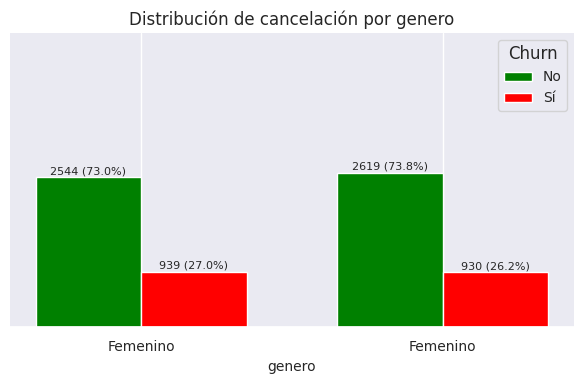

In [648]:
cancelacion(df, ['genero'], labels_dict={'genero': ['Masculino', 'Femenino']})

- Cancelación según el veterano

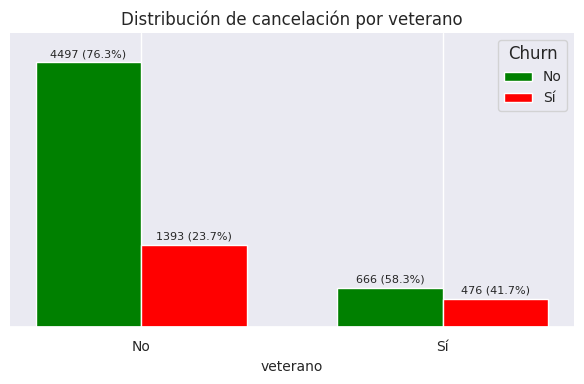

In [649]:
cancelacion(df, ['veterano'], labels_dict={'veterano': ['No', 'Sí']})

- Cancelación según el estado civil

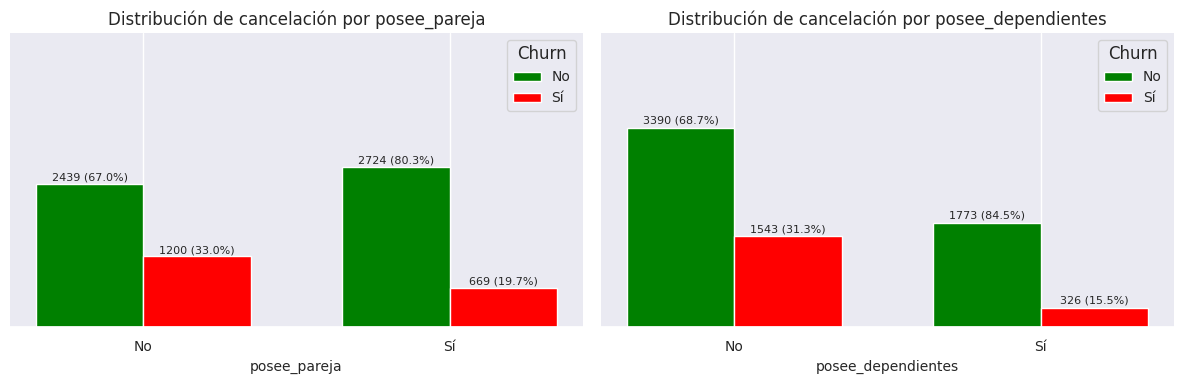

In [650]:
cancelacion(df, ['posee_pareja', 'posee_dependientes'], labels_dict={'Estado Civil': ['Soltero', 'Casado']})

- Cancelacion de servicio telefónico

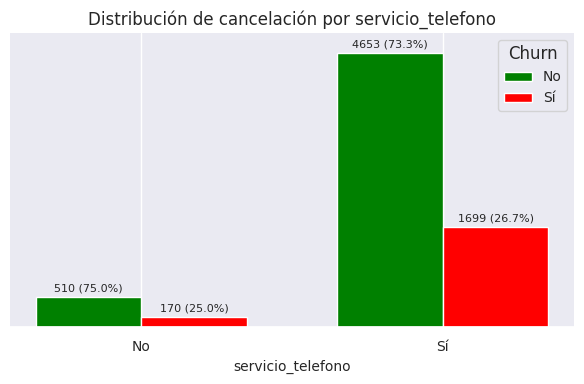

In [651]:
cancelacion(df, ['servicio_telefono'])

- Cancelación por factura digital.

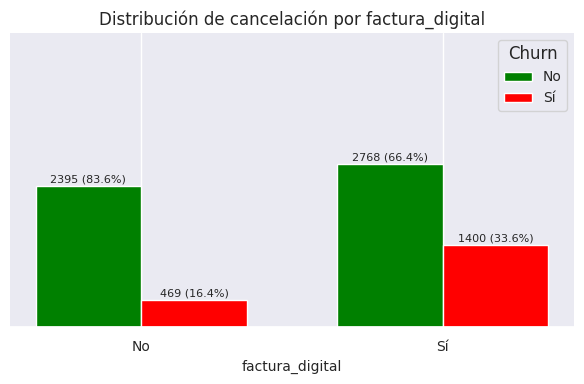

In [652]:
cancelacion(df, ['factura_digital'])

- Resumen por categorias.

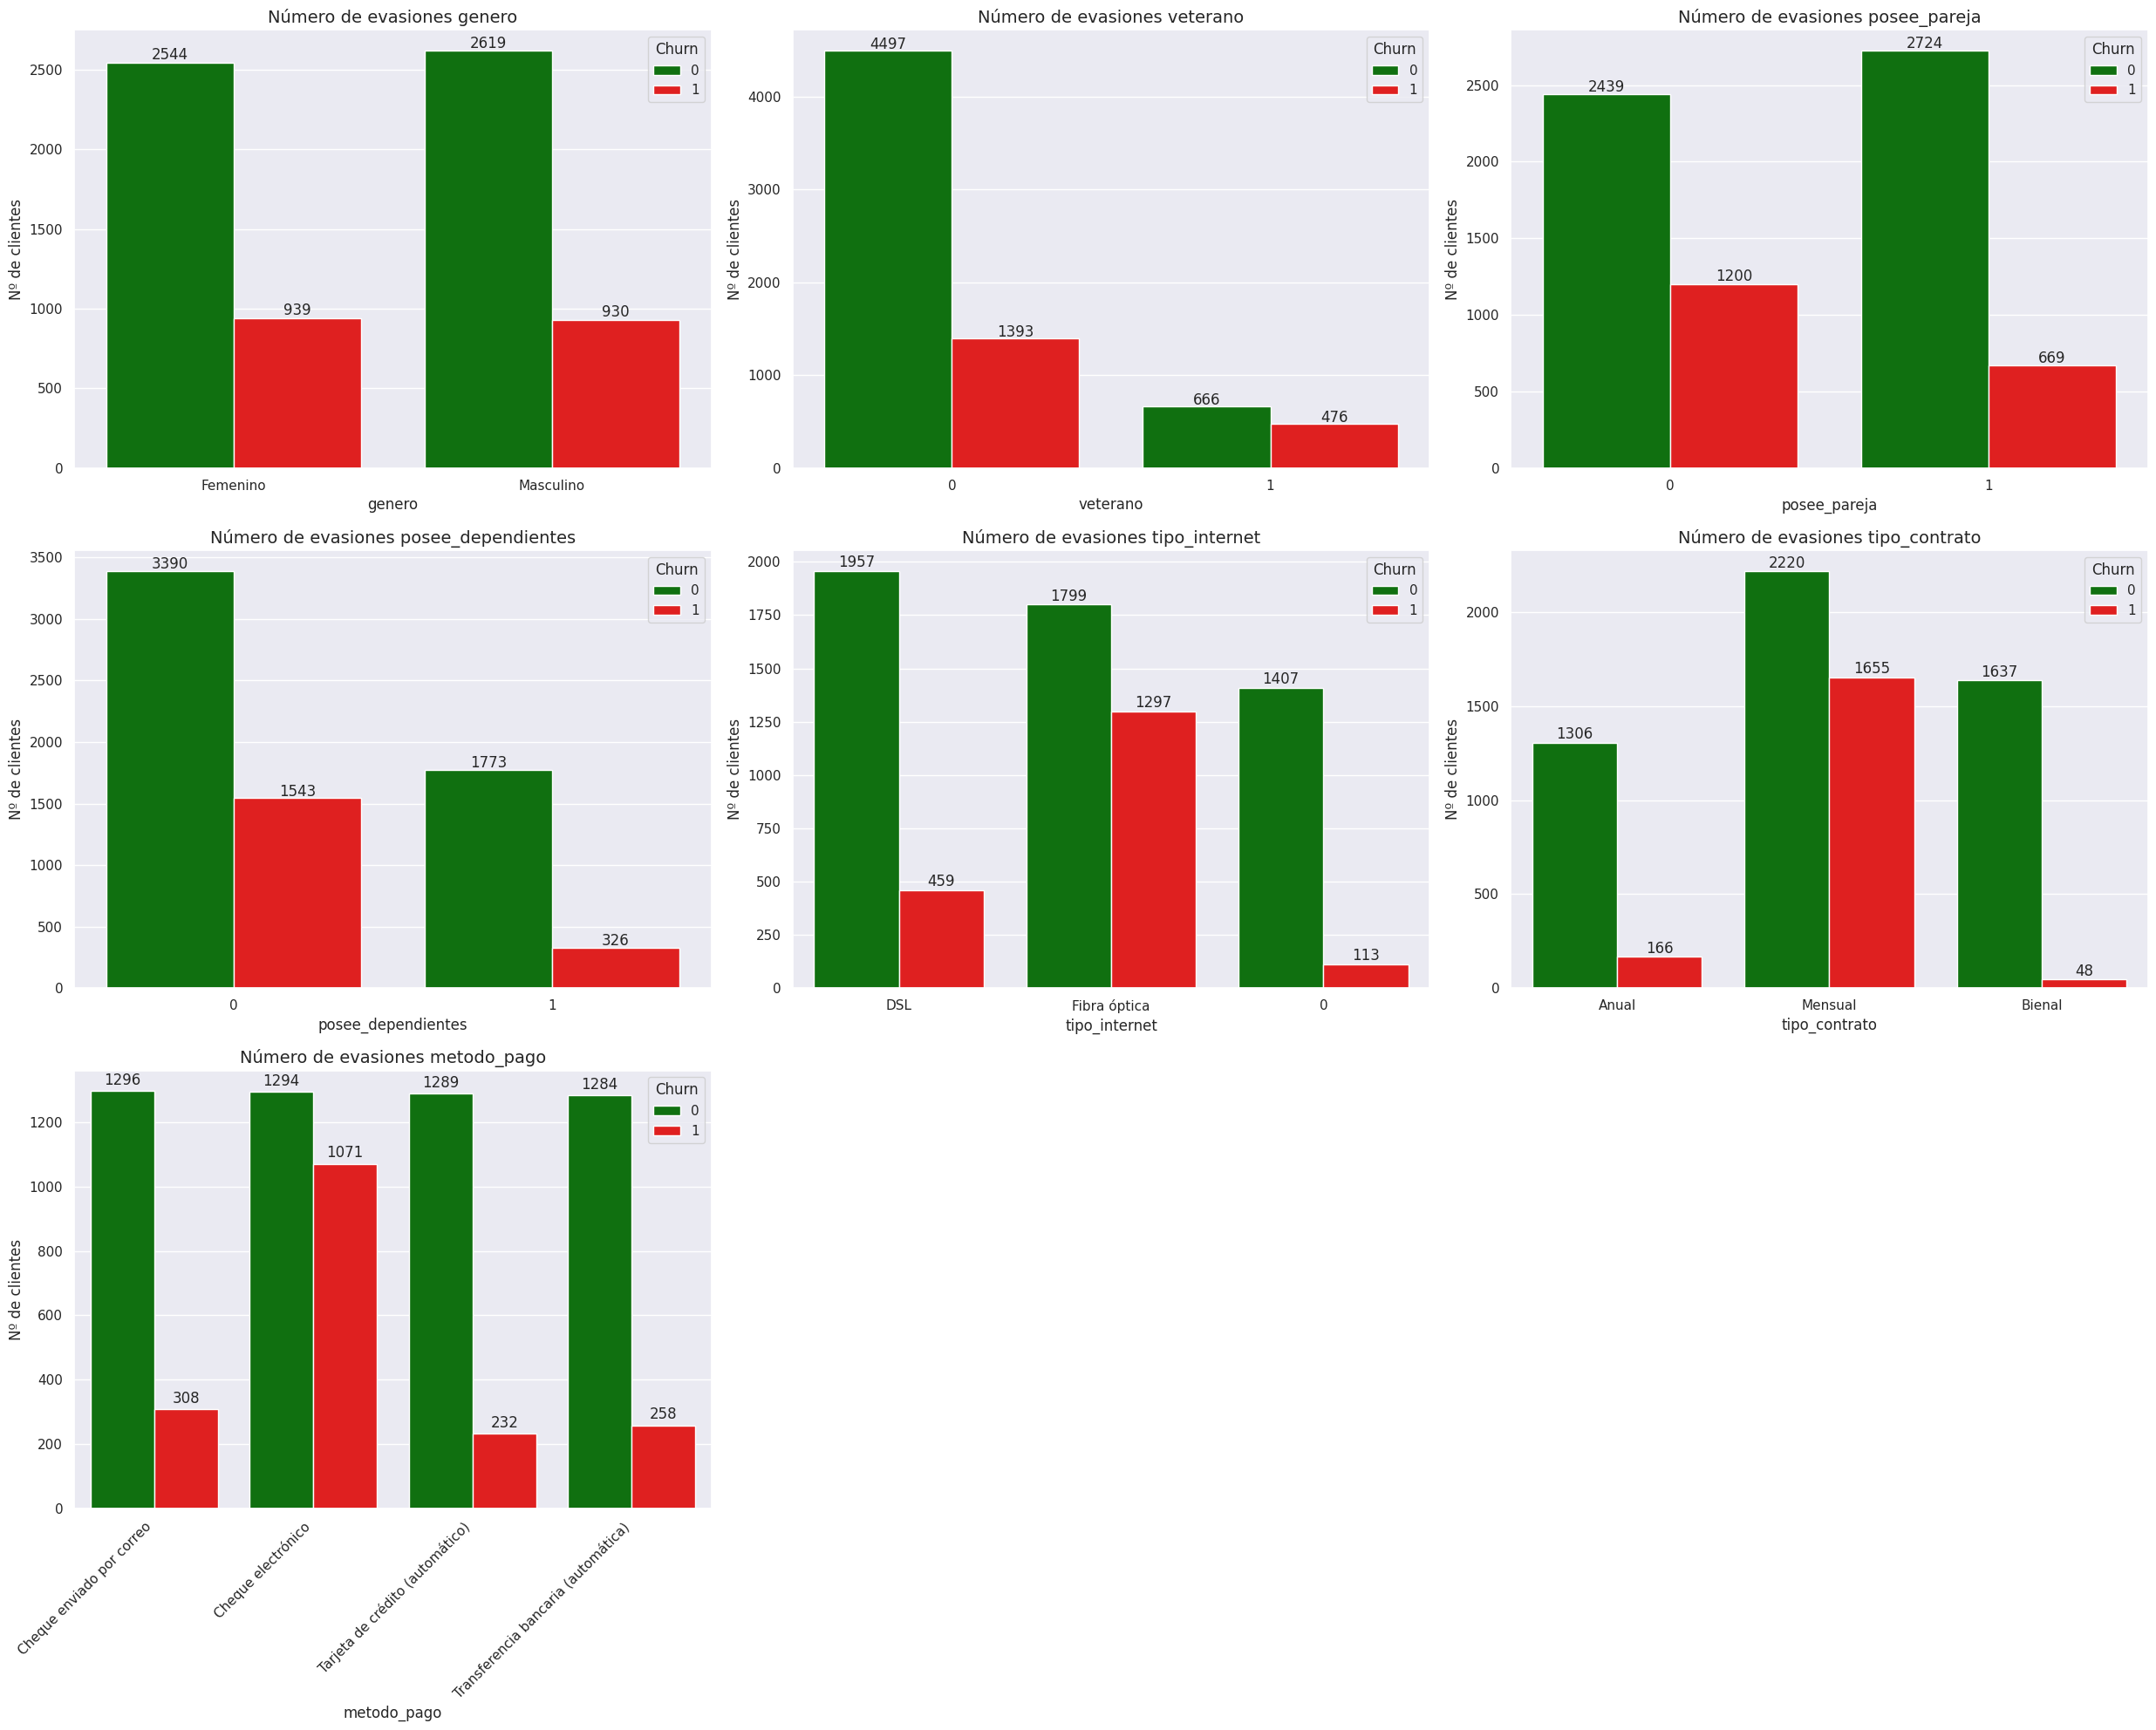

In [653]:
variables_categoricas = ['genero', 'veterano', 'posee_pareja',
                        'posee_dependientes', 'tipo_internet',
                         'tipo_contrato', 'metodo_pago',]

lista_variables_categoricas = list(enumerate(variables_categoricas))

sns.set(rc = {'figure.figsize':(25,20)})

for i in lista_variables_categoricas:

    plt.subplot(3, 3,  i[0]+1)
    ax = sns.countplot(data = df,
                    x = i[1],
                    hue = 'Churn',
                    palette = {0: 'green', 1: 'red'},
                    )

    ax.set_title(f'Número de evasiones {i[1]}', fontsize = 14)
    ax.set_ylabel('Nº de clientes', fontsize = 12)
    ax.set_xlabel(i[1], fontsize = 12)


    if i[1] == 'metodo_pago':
        plt.xticks(rotation=45, ha='right')


    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x()+p.get_width()/2.,
            height + 20,
            '{:1.0f}'.format(height),
            ha='center',
            size = 12)

plt.tight_layout()
plt.show()


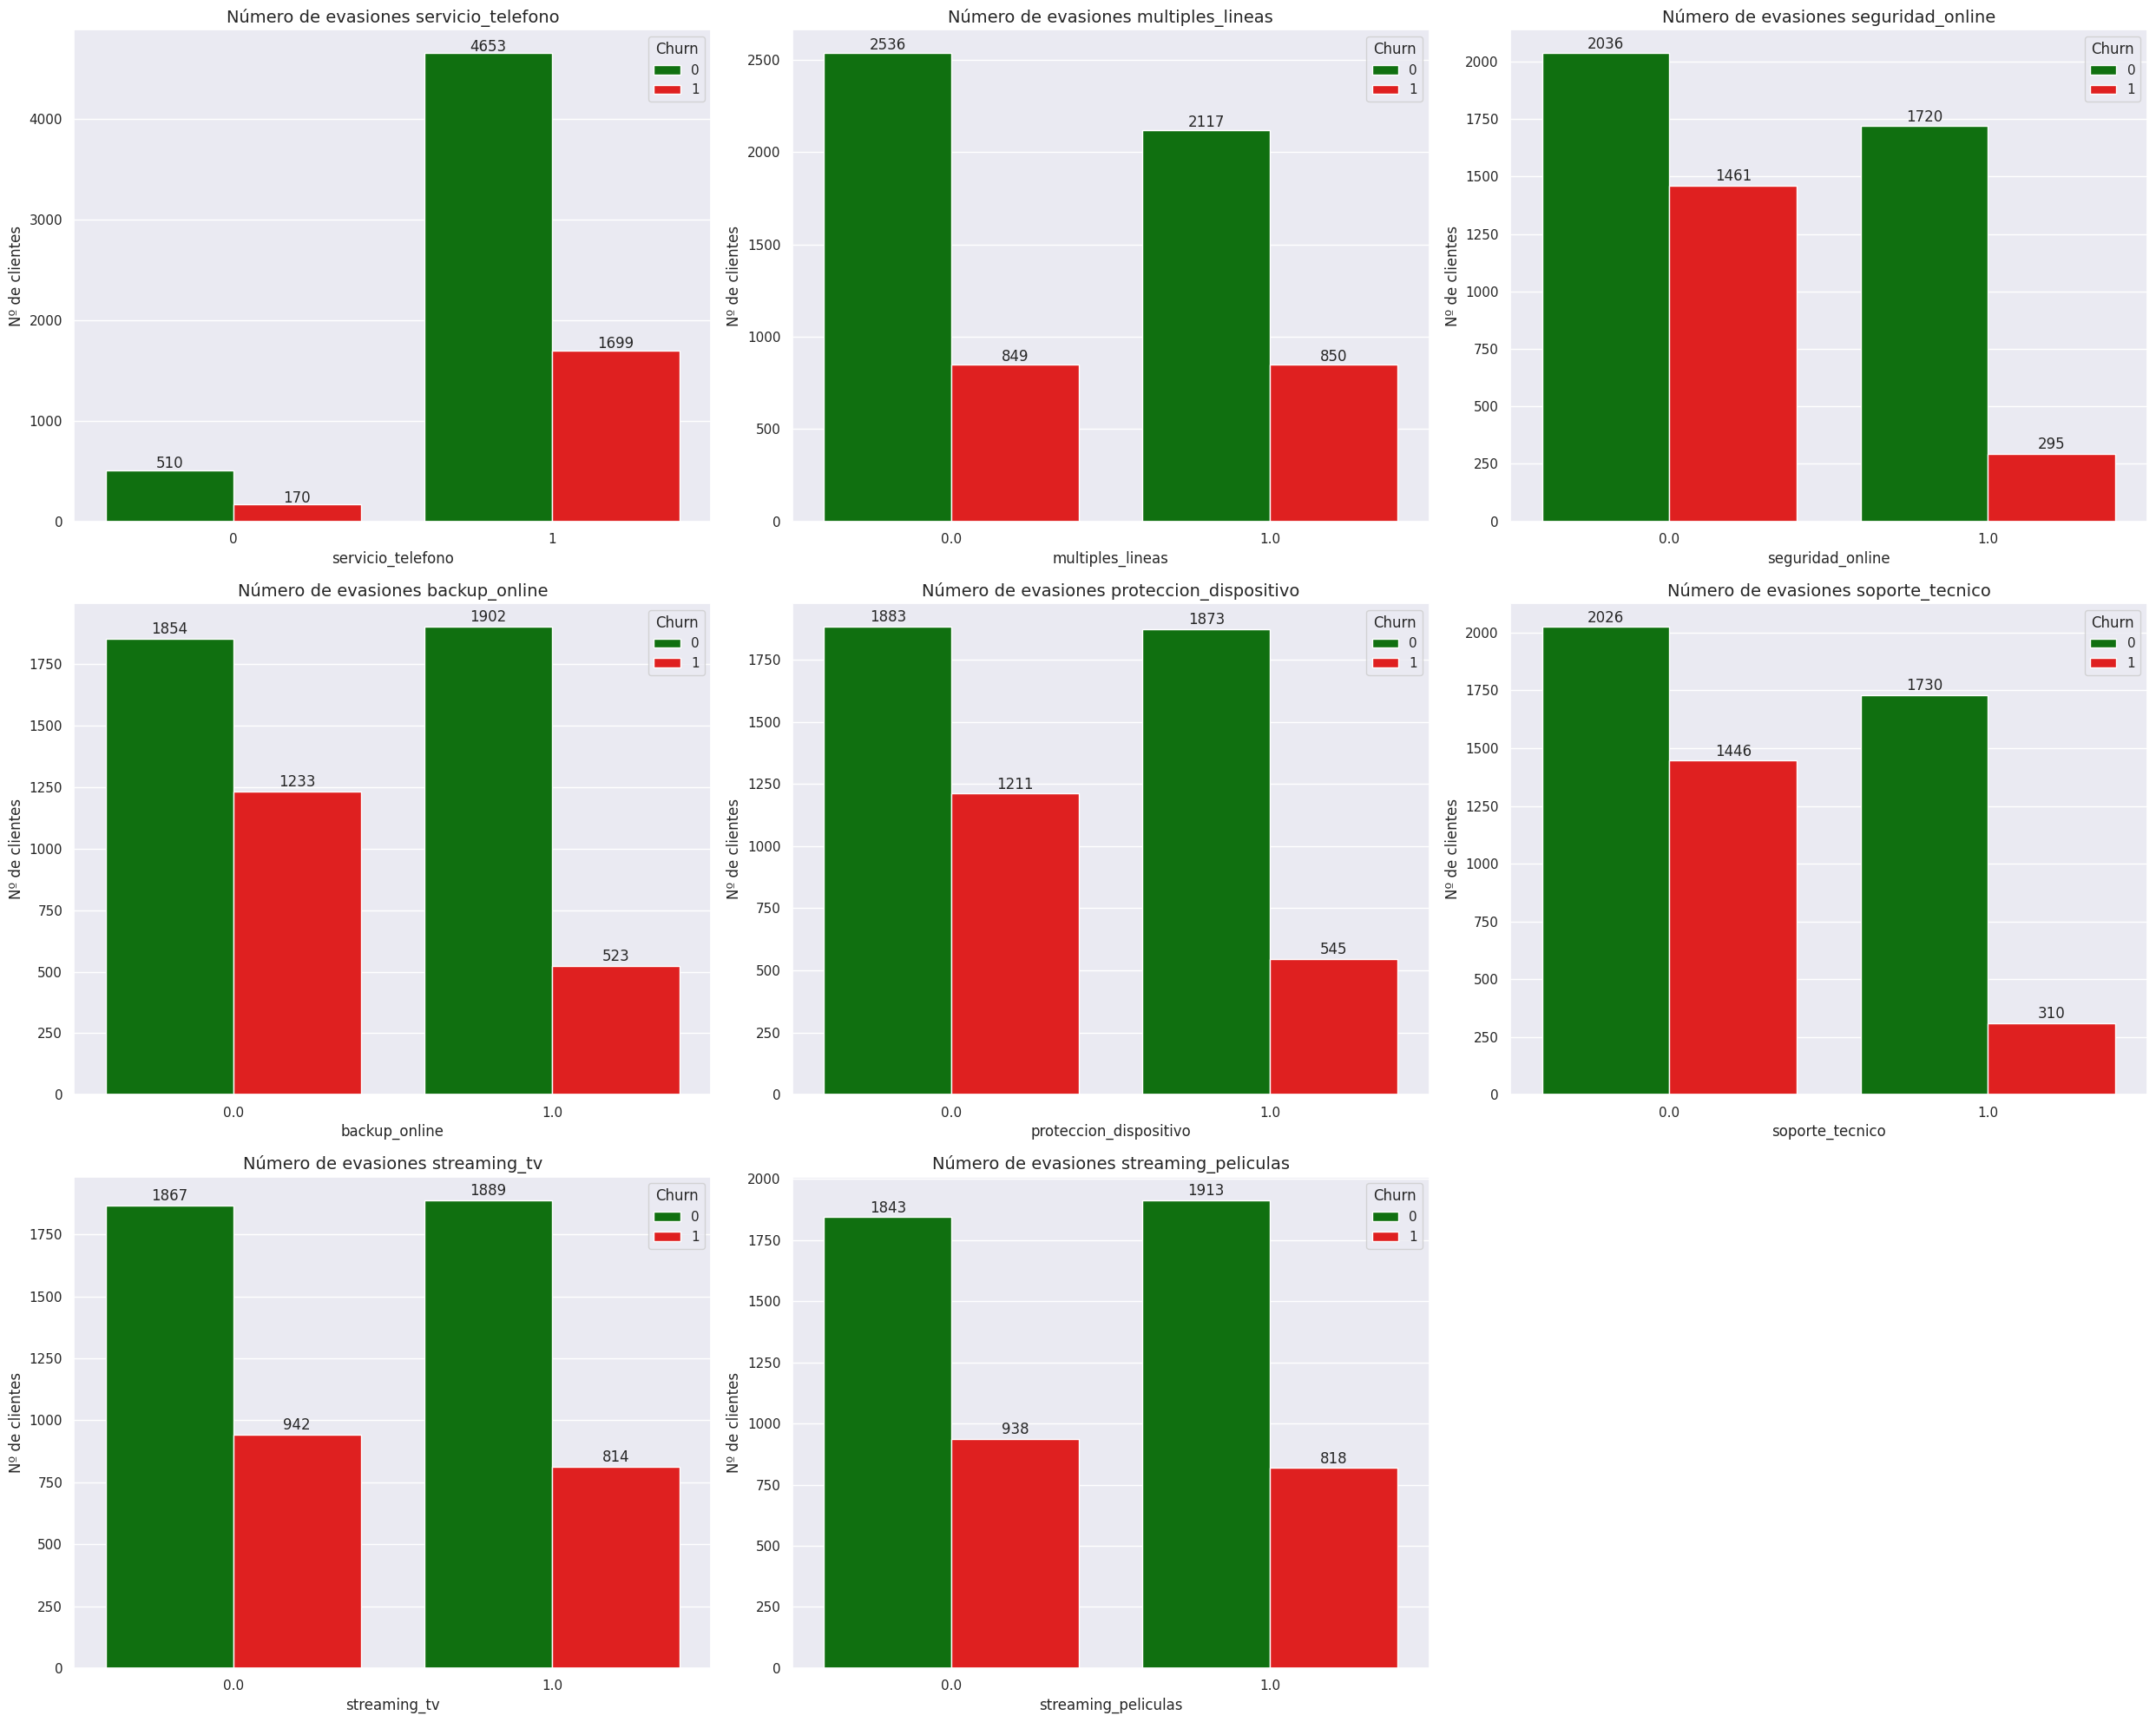

In [654]:

variables_categoricas = ['servicio_telefono', 'multiples_lineas', 'seguridad_online',
                        'backup_online', 'proteccion_dispositivo',
                         'soporte_tecnico', 'streaming_tv', 'streaming_peliculas',]

lista_variables_categoricas = list(enumerate(variables_categoricas))

sns.set(rc = {'figure.figsize':(25,20)})

for i in lista_variables_categoricas:

    plt.subplot(3, 3,  i[0]+1)
    ax = sns.countplot(data = df,
                    x = i[1],
                    hue = 'Churn',
                    palette = {0: 'green', 1: 'red'},
                    )

    ax.set_title(f'Número de evasiones {i[1]}', fontsize = 14)
    ax.set_ylabel('Nº de clientes', fontsize = 12)
    ax.set_xlabel(i[1], fontsize = 12)


    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x()+p.get_width()/2.,
            height + 20,
            '{:1.0f}'.format(height),
            ha='center',
            size = 12)

plt.tight_layout()
plt.show()

- Conteo de evasión por variables numéricas.

En este paso, explora cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la evasión, proporcionando insights sobre los factores que influyen en el comportamiento de los clientes.

In [655]:

df_grouped = df.groupby(['tiempo_contrato', 'Churn']).size().unstack(fill_value=0)

df_grouped['churn_rate'] = (df_grouped.get(1, 0) / df_grouped.sum(axis=1)) * 100


df_grouped = df.groupby(['tiempo_contrato', 'Churn']).size().unstack(fill_value=0)

df_grouped['churn_rate'] = (df_grouped.get(1, 0) / df_grouped.sum(axis=1)) * 100

fig = px.line(df_grouped.reset_index(),
              x='tiempo_contrato',
              y='churn_rate',
              markers=True,
              title='Tasa de Churn (%) por tiempo_contrato',
              color_discrete_sequence=['red']
             )

fig.update_layout(title_x=0.5)
fig.update_traces(hovertemplate='tiempo_contrato=%{x}tasa de Churn=%{y:.1f}%')
fig.update_xaxes(title_text='tiempo_contrato (meses)')
fig.show()

- Cancelación de clientes por contrato.

In [656]:
df_grouped = (
    df.groupby(['tiempo_contrato', 'Churn'])
    .size()
    .reset_index(name='cantidad')
)
df_grouped['Churn_Label'] = df_grouped['Churn'].map({0: '0', 1: '1'})


colores_churn = {
    '0': 'green',
    '1': 'red'
}


fig = px.bar(
    df_grouped,
    x='tiempo_contrato',
    y='cantidad',
    color='Churn_Label',
    text='cantidad',
    barmode='group',
    color_discrete_map=colores_churn,
    category_orders={"Churn_Label": ['0', '1']}
)

fig.update_traces(
    textposition='outside',
    textangle=-90,
    cliponaxis=False,
    textfont=dict(
        size=22, #Tamaño
        family='Arial', #Fuente
    ),
    hovertemplate="Churn=%{fullData.name}Mes=%{x}Cantidad=%{y}"
)

#Configuración de ejes y layout
max_y = df_grouped['cantidad'].max()

fig.update_layout(
    title={'text': 'Distribución de cancelación de clientes', 'x': 0.5},
    xaxis_title='tiempo_contrato (meses)',
    yaxis_title='Cantidad de clientes',
    yaxis=dict(range=[0, max_y * 1.2], showgrid=True),
    xaxis=dict(tickmode='linear', dtick=5 if df_grouped['tiempo_contrato'].max() > 24 else 1),
    height=600,
    width=1180,
    legend_title_text='',  #Ocultamos el título de la etiqueta
    margin=dict(t=100, b=80, l=60, r=40),
    uniformtext=dict(minsize=6, mode='show'),

    legend=dict(
        x=0.98,
        y=0.98,
        xanchor='right',
        yanchor='top'
    ),
    annotations=[
        dict(
            xref='paper',
            yref='paper',
            x=1.05,
            y=0.98,
            text='Churn',
            showarrow=False,
            font=dict(size=14, color='black'),
            xanchor='left',
            yanchor='top'
        )
    ]
)

fig.show()

In [657]:
df_grouped = (
    df.groupby(['tiempo_contrato', 'Churn'])
    .size()
    .reset_index(name='cantidad')
)
df_grouped['Churn_Label'] = df_grouped['Churn'].map({0: '0', 1: '1'})


df_grouped['total_por_contrato'] = df_grouped.groupby('tiempo_contrato')['cantidad'].transform('sum')
df_grouped['porcentaje'] = (df_grouped['cantidad'] / df_grouped['total_por_contrato'] * 100).round(1)
df_grouped['texto_porcentaje'] = df_grouped['porcentaje'].astype(str) + '%'

#Colores
colores_churn = {
    '0': 'green',
    '1': 'red'
}

#Creación de la gráfica
fig = px.bar(
    df_grouped,
    x='tiempo_contrato',
    y='cantidad',
    color='Churn_Label',
    text='texto_porcentaje',
    barmode='group',
    color_discrete_map=colores_churn,
    category_orders={"Churn_Label": ['0', '1']}
)

#Ajustes de trazos
fig.update_traces(
    textposition='outside',
    textangle=-90,
    cliponaxis=False,
    textfont=dict(
        size=10,
        family='Arial',
    ),
    hovertemplate="Churn=%{fullData.name}Mes=%{x}Cantidad=%{y}Porcentaje=%{customdata:.1f}%",
    customdata=df_grouped['porcentaje']
)

#Configuración de ejes y layout
max_y = df_grouped['cantidad'].max()

fig.update_layout(
    title={'text': 'Distribución de cancelación de clientes', 'x': 0.5},
    xaxis_title='tiempo del contrato (meses)',
    yaxis_title='% cancelación',
    yaxis=dict(range=[0, max_y * 1.2], showgrid=True),
    xaxis=dict(tickmode='linear', dtick=5 if df_grouped['tiempo_contrato'].max() > 24 else 1),
    height=600,
    width=1180,
    legend_title_text='',
    margin=dict(t=100, b=80, l=60, r=40),
    uniformtext=dict(minsize=6, mode='show'),

    legend=dict(
        x=0.98,
        y=0.98,
        xanchor='right',
        yanchor='top'
    ),
    annotations=[
        dict(
            xref='paper',
            yref='paper',
            x=1.05,
            y=0.98,
            text='Churn',
            showarrow=False,
            font=dict(size=14, color='black'),
            xanchor='left',
            yanchor='top'
        )
    ]
)

fig.show()

In [658]:
colores_churn = {
     0: 'green',
     1: 'red'
}

variables_a_plotear = ['tiempo_contrato', 'valor_mensual', 'total_cobrado', 'cuentas_diarias']
subplot_titles = ['Evasión tiempo_contrato', 'Evasión valor_mensual', 'Evasión total_cobrado', 'Evasión cuentas_diarias']

fig = make_subplots(rows=1, cols=4,
                    subplot_titles=subplot_titles,
                    horizontal_spacing=0.08,
                    vertical_spacing=0.05)

seen_legend_items = set()
for i, var in enumerate(variables_a_plotear):
    fig_temp = px.box(df,
                      x = 'Churn',
                      y = var,
                      color = 'Churn',
                      color_discrete_map=colores_churn)


    for trace in fig_temp.data:
        legend_group_name = trace.name # '0' o '1'.
        trace.showlegend = legend_group_name not in seen_legend_items
        if legend_group_name not in seen_legend_items:
            seen_legend_items.add(legend_group_name)

        fig.add_trace(trace, row=1, col=i+1)


    fig.update_yaxes(showticklabels=True, title_text=var, title_standoff=5, automargin=True, row=1, col=i+1)
    fig.update_xaxes(showticklabels=True, title_text='Churn', row=1, col=i+1)


for annotation in fig.layout.annotations:
    if annotation.yref == 'paper' and annotation.y > 0.95:
        annotation.y = 1.03

fig.update_layout(title_text='Distribución de cancelación por variables numéricas',
                  title_x=0.5,
                  title_y=0.92,
                  height=450,
                  margin=dict(l=30, r=60, t=120, b=10),
                  width=1134,
                  showlegend=True
                 )

fig.show()

- Análisis de correlación entre variables

 Explorar la correlación entre diferentes variables del dataset. Esto puede ayudar a identificar qué factores tienen mayor relación con la evasión de clientes, como:

🔹 La relación entre la cuenta diaria y la evasión.

🔹 Cómo la cantidad de servicios contratados afecta la probabilidad de churn.

Puedes usar la función corr() de Pandas para calcular las correlaciones y visualizar los resultados con gráficos de dispersión o matrices de correlación.

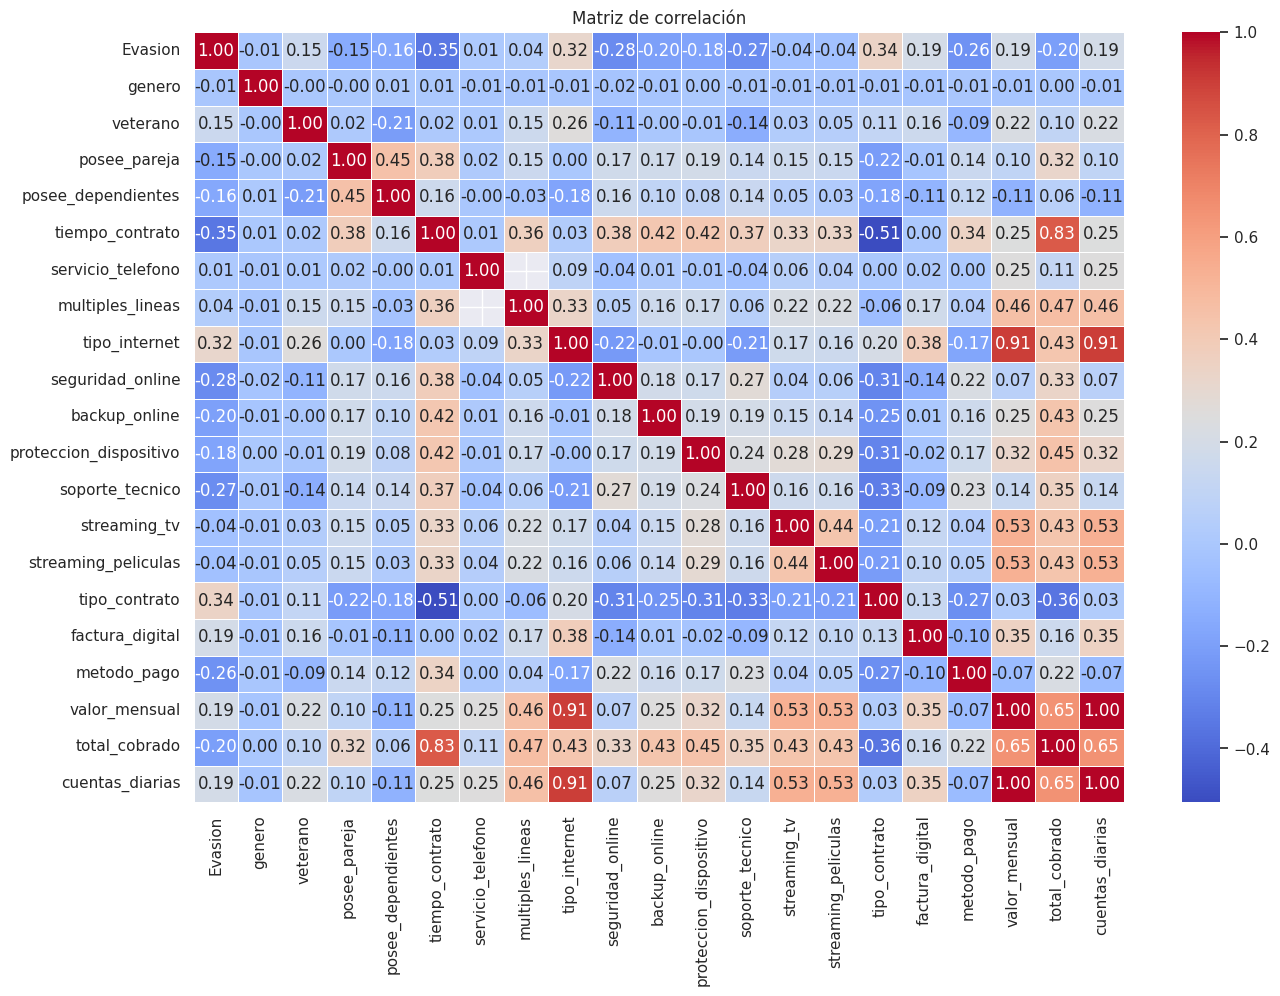

Evasion                   1.00
tipo_contrato             0.34
tipo_internet             0.32
cuentas_diarias           0.19
valor_mensual             0.19
factura_digital           0.19
veterano                  0.15
multiples_lineas          0.04
servicio_telefono         0.01
genero                   -0.01
streaming_tv             -0.04
streaming_peliculas      -0.04
posee_pareja             -0.15
posee_dependientes       -0.16
proteccion_dispositivo   -0.18
backup_online            -0.20
total_cobrado            -0.20
metodo_pago              -0.26
soporte_tecnico          -0.27
seguridad_online         -0.28
tiempo_contrato          -0.35


In [659]:
df_corr = df.copy()


for col in df_corr.select_dtypes(include=['object']).columns:
    if col != 'ID':
        df_corr[col] = df_corr[col].astype('category').cat.codes


df_corr = df_corr.rename(columns={'Churn': 'Evasion'})


correlation_matrix = df_corr.drop(columns=['ID']).corr()


plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación')
plt.show()


print(correlation_matrix['Evasion'].sort_values(ascending=False).round(2).to_string())

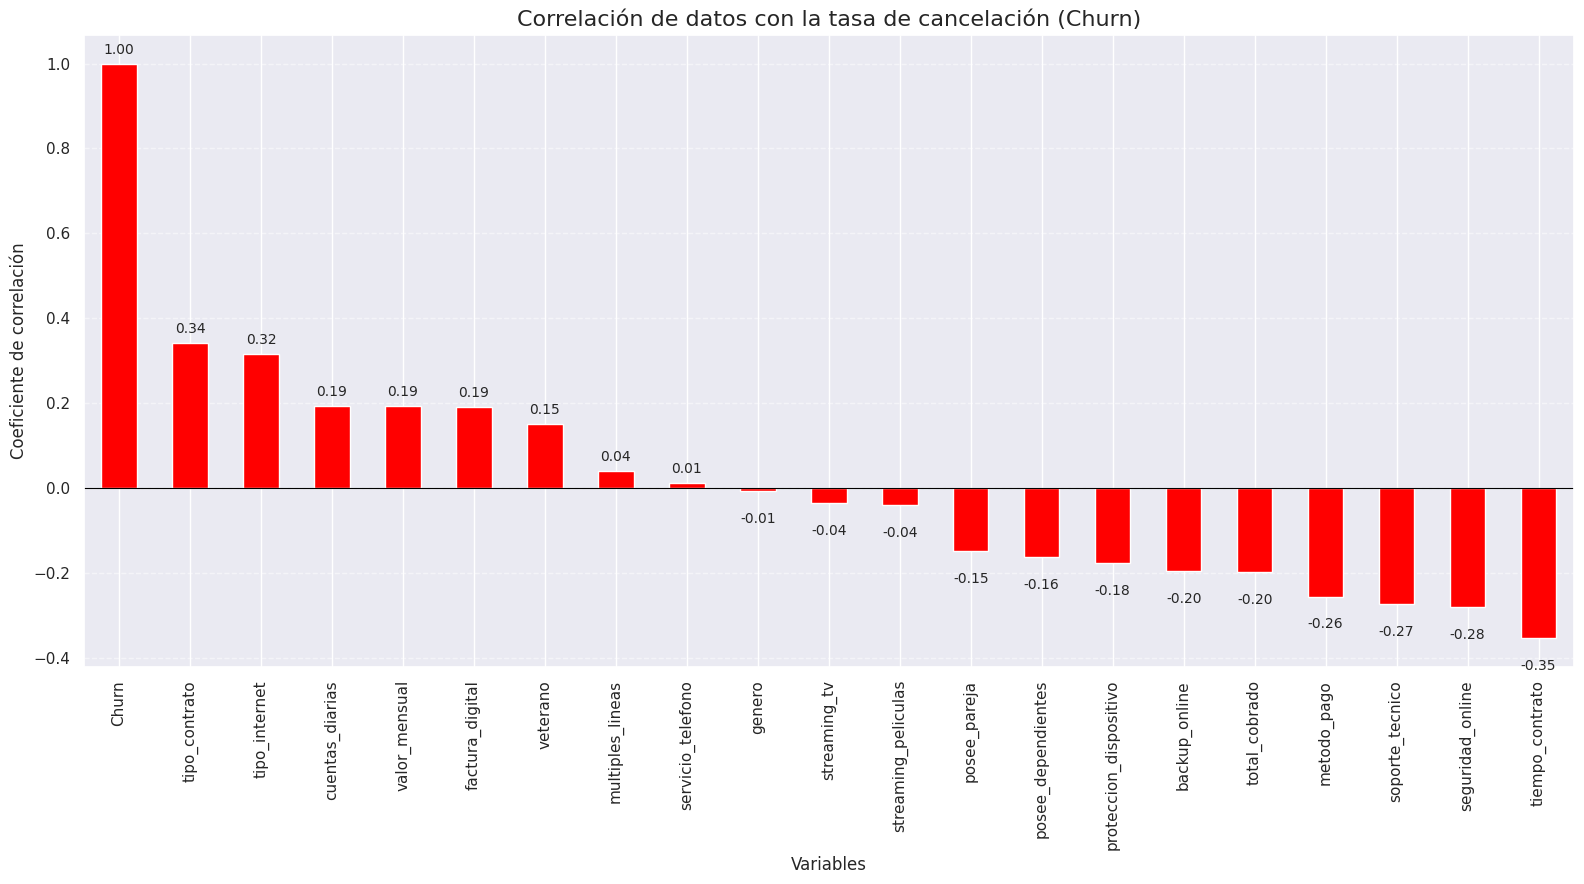

In [660]:
df_corr_processed = df.copy()
for col in df_corr_processed.select_dtypes(include=['object']).columns:
    if col != 'ID':
        df_corr_processed[col] = df_corr_processed[col].astype('category').cat.codes

df_corr_processed = df_corr_processed.drop(columns=['ID'])

#Creación del gráfico
plt.figure(figsize=(16, 9))
correlaciones = df_corr_processed.corr()['Churn'].sort_values(ascending=False)
ax = correlaciones.plot(kind='bar', color='red')


for p in ax.patches:
    height = p.get_height()
    va_position = 'bottom' if height > 0 else 'top'
    offset = 5 if height > 0 else -15

    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va=va_position,
                xytext=(0, offset),
                textcoords='offset points',
                fontsize=10)

plt.title('Correlación de datos con la tasa de cancelación (Churn)', fontsize=16)
plt.ylabel('Coeficiente de correlación', fontsize=12)
plt.xlabel('Variables', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#📄Informe final

La compañía TelecomX tiene una cancelación del servicio con un porcentaje de 26,6%.

Esto se debe principalmente al:
Mal soporte técnico que reciben los clientes, las tarifas son muy costosas. No se otorgan servicios complementarios a los clientes, en su defecto estos servicios (seguridad de linea, respaldo en linea, protección de dispositivo y soporte técnico), deben ser contratados por los clientes y esto aumenta la facturación provocando que los clientes que tiene contrato mensual tengas mas probabilidades de abandono.

Se deben mejorar las tarifas, proporcionar un mejor servicio de atención al cliente con relación al soporte técnico.
